In [3]:
# Установка необходимых пакетов (если не установлены)
!pip install -q seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Используем tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import set_random_seed

# Настройка воспроизводимости
set_random_seed(45)
np.random.seed(45)

print("Библиотеки загружены")

Текущая кодовая страница: 1251
Библиотеки загружены


In [5]:
# Скачивание и распаковка данных с помощью Python (без wget/tar)
import urllib.request
import zipfile 
import tarfile
import os

url = "https://www.dropbox.com/s/ufbhk3kadtnn6h0/yelp_review_polarity_csv.tgz?dl=1"
file_name = "yelp_review_polarity_csv.tgz"

# Скачивание
print("Скачивание файла...")
urllib.request.urlretrieve(url, file_name)
print("Скачивание завершено.")

# Распаковка
print("Распаковка...")
with tarfile.open(file_name, "r:gz") as tar:
    tar.extractall()
print("Распаковка завершена.")

# Просмотр содержимого (альтернатива ls)
print("Содержимое папки yelp_review_polarity_csv:")
for item in os.listdir("yelp_review_polarity_csv"):
    print(item)

Скачивание файла...
Скачивание завершено.
Распаковка...


C:\Users\veron\AppData\Local\Temp\ipykernel_11792\1735818438.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Распаковка завершена.
Содержимое папки yelp_review_polarity_csv:
readme.txt
test.csv
train.csv


In [7]:
# Чтение данных из CSV
import pandas as pd

train = pd.read_csv('yelp_review_polarity_csv/train.csv', header=None, names=['Class', 'Review'])
test = pd.read_csv('yelp_review_polarity_csv/test.csv', header=None, names=['Class', 'Review'])

print(f"Размер обучающей выборки: {train.shape}")
print(f"Размер тестовой выборки: {test.shape}")
print("\nПример отзыва из train:")
print(train['Review'].iloc[0])

Размер обучающей выборки: (560000, 2)
Размер тестовой выборки: (38000, 2)

Пример отзыва из train:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.


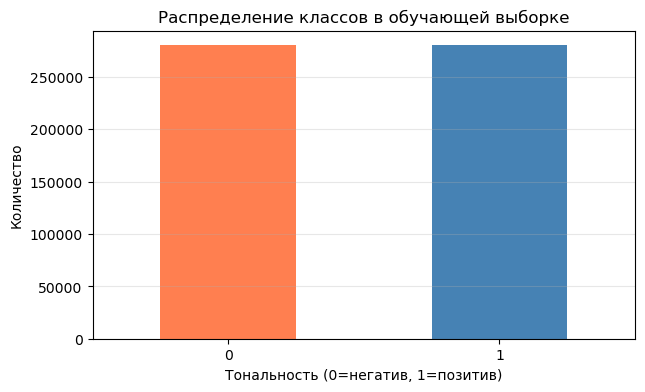

In [8]:
y_train = train['Class'] - 1  # станет 0 (негатив) и 1 (позитив)
y_test = test['Class'] - 1

plt.figure(figsize=(7,4))
y_train.value_counts().plot(kind='bar', color=['coral', 'steelblue'])
plt.title('Распределение классов в обучающей выборке')
plt.xlabel('Тональность (0=негатив, 1=позитив)')
plt.ylabel('Количество')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [10]:
# Основные параметры
num_words = 10000          # размер словаря
embedding_dim = 64         # размерность эмбеддинга
max_review_len = 100       # максимальная длина отзыва (в токенах)
batch_size = 128
epochs = 5
lstm_units = 128

In [12]:
# Токенизация и преобразование текста
# Токенизация — процесс разбиения текста на мин смысловые единицы — токены
reviews = train['Review'].values
tokenizer = Tokenizer(num_words=num_words)
tokenizer.fit_on_texts(reviews)
# Токенизатор сканирует все отзывы, разбивает их на слова,подсчитывает частоту каждого слова и сроит слова

sequences = tokenizer.texts_to_sequences(reviews)
x_train = pad_sequences(sequences, maxlen=max_review_len)

print(f"Размер x_train: {x_train.shape}")
print(f"Пример последовательности (первые 20): {x_train[0][:20]}")

Размер x_train: (560000, 100)
Пример последовательности (первые 20): [   7    1  137  112   24   18   27  189   80 3128   10 2636   34 1416
  462  129    8  519   13  177]


In [13]:
# Создание и обучение модели LSTM
model_lstm = Sequential([
    Embedding(num_words, embedding_dim, input_length=max_review_len),
    LSTM(lstm_units),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

# Callback для сохранения лучшей модели
checkpoint = ModelCheckpoint('best_lstm.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

history_lstm = model_lstm.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=[checkpoint],
    verbose=1
)

C:\Users\veron\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.8907 - loss: 0.2578   
Epoch 1: val_accuracy improved from None to 0.95014, saving model to best_lstm.h5



Epoch 1: finished saving model to best_lstm.h5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1042s 263ms/step - accuracy: 0.9190 - loss: 0.2035 - val_accuracy: 0.9501 - val_loss: 0.1267
Epoch 2/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9433 - loss: 0.1479   
Epoch 2: val_accuracy improved from 0.95014 to 0.95395, saving model to best_lstm.h5



Epoch 2: finished saving model to best_lstm.h5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1094s 278ms/step - accuracy: 0.9458 - loss: 0.1415 - val_accuracy: 0.9539 - val_loss: 0.1165
Epoch 3/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9538 - loss: 0.1232   
Epoch 3: val_accuracy improved from 0.95395 to 0.95525, saving model to best_lstm.h5



Epoch 3: finished saving model to best_lstm.h5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1074s 271ms/step - accuracy: 0.9558 - loss: 0.1185 - val_accuracy: 0.9553 - val_loss: 0.1189
Epoch 4/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9617 - loss: 0.1043   
Epoch 4: val_accuracy did not improve from 0.95525
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1113s 283ms/step - accuracy: 0.9634 - loss: 0.1000 - val_accuracy: 0.9543 - val_loss: 0.1250
Epoch 5/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.9685 - loss: 0.0876   
Epoch 5: val_accuracy did not improve from 0.95525
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1134s 288ms/step - accuracy: 0.9699 - loss: 0.0840 - val_accuracy: 0.9525 - val_loss: 0.1385


Точность на тестовой выборке (LSTM): 0.9439
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step


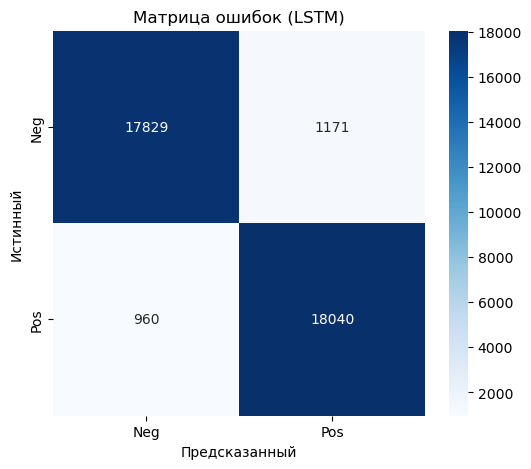

In [17]:
# Оценка LSTM на тестовых данных
# LSTM — это тип рекуррентной нейронной сети, предназнач для обработки послед данных и запоминания инфы на длительных интервалах. 
# Подготовка тестовых данных
test_sequences = tokenizer.texts_to_sequences(test['Review'].values)
x_test = pad_sequences(test_sequences, maxlen=max_review_len)

# Загрузка лучшей модели
model_lstm.load_weights('best_lstm.h5')

# Оценка
loss, acc = model_lstm.evaluate(x_test, y_test, verbose=0)
print(f"Точность на тестовой выборке (LSTM): {acc:.4f}")

# Матрица ошибок
y_pred_lstm = (model_lstm.predict(x_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Матрица ошибок (LSTM)')
plt.xlabel('Предсказанный')
plt.ylabel('Истинный')
plt.show()

In [18]:
# GRU — это упрощённый вариант LSTM, также относящийся к рекуррентным сетям.
# Обучение модели GRU для сравнения
model_gru = Sequential([
    Embedding(num_words, embedding_dim, input_length=max_review_len),
    GRU(lstm_units),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gru.summary()

checkpoint_gru = ModelCheckpoint('best_gru.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

history_gru = model_gru.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,
    callbacks=[checkpoint_gru],
    verbose=1
)

C:\Users\veron\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8796 - loss: 0.2771  
Epoch 1: val_accuracy improved from None to 0.95293, saving model to best_gru.h5



Epoch 1: finished saving model to best_gru.h5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 386s 98ms/step - accuracy: 0.9160 - loss: 0.2083 - val_accuracy: 0.9529 - val_loss: 0.1227
Epoch 2/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9438 - loss: 0.1442  
Epoch 2: val_accuracy improved from 0.95293 to 0.95625, saving model to best_gru.h5



Epoch 2: finished saving model to best_gru.h5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 376s 95ms/step - accuracy: 0.9469 - loss: 0.1373 - val_accuracy: 0.9563 - val_loss: 0.1115
Epoch 3/5
3937/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9547 - loss: 0.1186  
Epoch 3: val_accuracy improved from 0.95625 to 0.95627, saving model to best_gru.h5



Epoch 3: finished saving model to best_gru.h5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 383s 97ms/step - accuracy: 0.9568 - loss: 0.1139 - val_accuracy: 0.9563 - val_loss: 0.1120
Epoch 4/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9634 - loss: 0.0981  
Epoch 4: val_accuracy did not improve from 0.95627
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 394s 100ms/step - accuracy: 0.9654 - loss: 0.0939 - val_accuracy: 0.9543 - val_loss: 0.1254
Epoch 5/5
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9718 - loss: 0.0783  
Epoch 5: val_accuracy did not improve from 0.95627
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 387s 98ms/step - accuracy: 0.9734 - loss: 0.0748 - val_accuracy: 0.9510 - val_loss: 0.1524


Точность GRU: 0.9464
Точность LSTM: 0.9439
Разница: 0.0025


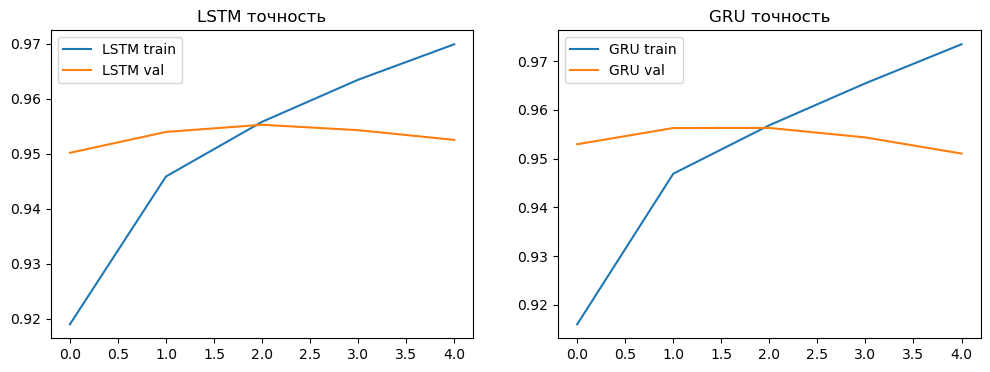

In [19]:
# Сравнение качества LSTM vs GRU
model_gru.load_weights('best_gru.h5')
loss_gru, acc_gru = model_gru.evaluate(x_test, y_test, verbose=0)
print(f"Точность GRU: {acc_gru:.4f}")
print(f"Точность LSTM: {acc:.4f}")
print(f"Разница: {acc_gru - acc:.4f}")

# Визуализация кривых обучения
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='LSTM train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM val')
plt.title('LSTM точность')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history_gru.history['accuracy'], label='GRU train')
plt.plot(history_gru.history['val_accuracy'], label='GRU val')
plt.title('GRU точность')
plt.legend()
plt.show()

In [20]:
# Эксперимент 1 – изменение размерности эмбеддинга
# Эмбеддинг — это слой нейронной сети, который преобр дискретные категориальные данные в плотные векторы фиксированной размерности
# Эксперимент: embedding_dim = 128 вместо 64
embedding_dim_exp1 = 128
model_exp1 = Sequential([
    Embedding(num_words, embedding_dim_exp1, input_length=max_review_len),
    LSTM(lstm_units),
    Dense(1, activation='sigmoid')
])
model_exp1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_exp1.fit(x_train, y_train, batch_size=batch_size, epochs=3, validation_split=0.1, verbose=1)
loss1, acc1 = model_exp1.evaluate(x_test, y_test, verbose=0)
print(f"Embedding dim = 128, точность: {acc1:.4f}")
# Размерности 64 достаточно для словаря (улучшений нет), увелич эмб без увл данных может привести к переобучению

Epoch 1/3


C:\Users\veron\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3938/3938 ━━━━━━━━━━━━━━━━━━━━ 432s 109ms/step - accuracy: 0.9202 - loss: 0.2002 - val_accuracy: 0.9531 - val_loss: 0.1224
Epoch 2/3
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 416s 106ms/step - accuracy: 0.9475 - loss: 0.1373 - val_accuracy: 0.9565 - val_loss: 0.1146
Epoch 3/3
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 426s 108ms/step - accuracy: 0.9584 - loss: 0.1118 - val_accuracy: 0.9550 - val_loss: 0.1207
Embedding dim = 128, точность: 0.9439


In [21]:
# Эксперимент 2 – количество нейронов в LSTM

# Эксперимент: LSTM_units = 256
lstm_units_exp2 = 256
model_exp2 = Sequential([
    Embedding(num_words, embedding_dim, input_length=max_review_len),
    LSTM(lstm_units_exp2),
    Dense(1, activation='sigmoid')
])
model_exp2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_exp2.fit(x_train, y_train, batch_size=batch_size, epochs=3, validation_split=0.1, verbose=1)
loss2, acc2 = model_exp2.evaluate(x_test, y_test, verbose=0)
print(f"LSTM units = 256, точность: {acc2:.4f}")
# (чуть улучшилось) Увеличение ёмкости LSTM позволяет модели улавливать более сложные паттерны

Epoch 1/3


C:\Users\veron\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1561s 396ms/step - accuracy: 0.9189 - loss: 0.2041 - val_accuracy: 0.9512 - val_loss: 0.1267
Epoch 2/3
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1200s 299ms/step - accuracy: 0.9456 - loss: 0.1420 - val_accuracy: 0.9543 - val_loss: 0.1174
Epoch 3/3
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 1171s 297ms/step - accuracy: 0.9553 - loss: 0.1193 - val_accuracy: 0.9562 - val_loss: 0.1163
LSTM units = 256, точность: 0.9456


In [22]:
# Эксперимент 3 – изменение оптимизатора

# Эксперимент: оптимизатор RMSprop
model_exp3 = Sequential([
    Embedding(num_words, embedding_dim, input_length=max_review_len),
    LSTM(lstm_units),
    Dense(1, activation='sigmoid')
])
model_exp3.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model_exp3.fit(x_train, y_train, batch_size=batch_size, epochs=3, validation_split=0.1, verbose=1)
loss3, acc3 = model_exp3.evaluate(x_test, y_test, verbose=0)
print(f"Optimizer RMSprop, точность: {acc3:.4f}")
# (не изменилась) Оба оптимизатора дают практически одинаковый результат для этой задачи

C:\Users\veron\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 437s 110ms/step - accuracy: 0.9053 - loss: 0.2312 - val_accuracy: 0.9431 - val_loss: 0.1567
Epoch 2/3
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 434s 110ms/step - accuracy: 0.9383 - loss: 0.1591 - val_accuracy: 0.9519 - val_loss: 0.1286
Epoch 3/3
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 454s 115ms/step - accuracy: 0.9459 - loss: 0.1414 - val_accuracy: 0.9562 - val_loss: 0.1168
Optimizer RMSprop, точность: 0.9437


In [23]:
# Сводная таблица результатов экспериментов
results = pd.DataFrame({
    'Модель': ['Базовый LSTM', 'GRU', 'Embedding 128', 'LSTM units 256', 'RMSprop'],
    'Точность на тесте': [acc, acc_gru, acc1, acc2, acc3]
})
print(results)
# GRU имеет меньше параметров и обучается быстрее

           Модель  Точность на тесте
0    Базовый LSTM           0.943921
1             GRU           0.946421
2   Embedding 128           0.943921
3  LSTM units 256           0.945632
4         RMSprop           0.943737


In [24]:
# Проверка на собственных отзывах (положительный, отрицательный, нейтральный)

# Положительный отзыв
pos_review = "The food was amazing, service was great, definitely will come back!"
# Отрицательный отзыв
neg_review = "Terrible experience, dirty place, rude staff, never again."
# Нейтральный отзыв
neu_review = "The restaurant is average, nothing special, but not bad."

def predict_sentiment(text, model, tokenizer, max_len):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len)
    prob = model.predict(padded, verbose=0)[0][0]
    return prob, "положительный" if prob > 0.7 else ("отрицательный" if prob < 0.3 else "нейтральный")

print("=== Проверка на своих отзывах ===")
for name, txt in [("Положительный", pos_review), ("Отрицательный", neg_review), ("Нейтральный", neu_review)]:
    prob, sent = predict_sentiment(txt, model_lstm, tokenizer, max_review_len)
    print(f"{name} отзыв: вероятность позитива = {prob:.4f} -> тональность: {sent}")

=== Проверка на своих отзывах ===
Положительный отзыв: вероятность позитива = 0.9994 -> тональность: положительный
Отрицательный отзыв: вероятность позитива = 0.0010 -> тональность: отрицательный
Нейтральный отзыв: вероятность позитива = 0.1222 -> тональность: отрицательный


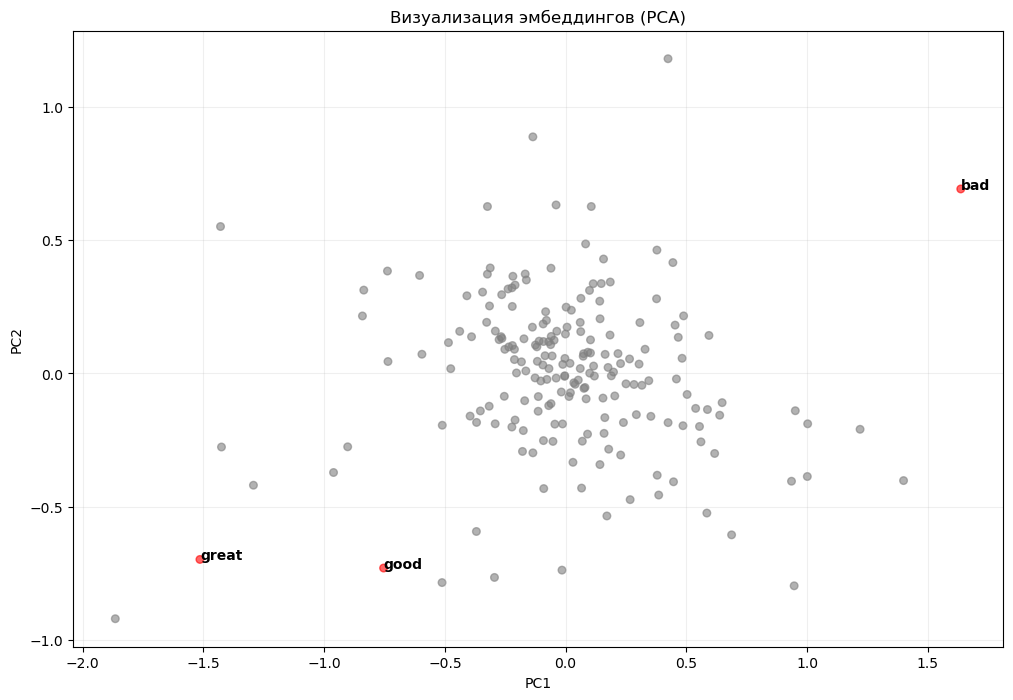

In [25]:
# Визуализация эмбеддингов (по примеру, используя PCA)
from sklearn.decomposition import PCA

# Получаем веса слоя Embedding из лучшей LSTM-модели
embedding_weights = model_lstm.layers[0].get_weights()[0]  # форма (num_words, embedding_dim)

# Выбираем 200 самых частотных слов (индексы 1..200)
words_to_plot = 200
emb_subset = embedding_weights[1:words_to_plot+1, :]  # пропускаем индекс 0 (padding)

# Понижение размерности до 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(emb_subset)

# Восстановление слов по индексам
index_to_word = {v: k for k, v in tokenizer.word_index.items()}
words = [index_to_word.get(i, '?') for i in range(1, words_to_plot+1)]

# Подсветка ключевых слов
highlight = ['good', 'great', 'excellent', 'bad', 'awful', 'poor']
colors = ['red' if w in highlight else 'gray' for w in words]
plt.figure(figsize=(12,8))
plt.scatter(coords[:,0], coords[:,1], c=colors, s=30, alpha=0.6)
for i, word in enumerate(words):
    if word in highlight:
        plt.annotate(word, (coords[i,0], coords[i,1]), fontsize=10, fontweight='bold')
plt.title('Визуализация эмбеддингов (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(alpha=0.2)
plt.show()

## Вывод по результатам лабораторной работы №5  
**«Определение тональности текстов отзывов сетями LSTM и GRU»**

В ходе работы была решена задача бинарной классификации отзывов Yelp (позитив / негатив) с использованием рекуррентных нейронных сетей. Проведено сравнение архитектур LSTM и GRU, выполнены три эксперимента по настройке гиперпараметров, а также выполнена проверка модели на собственных примерах.

### 1. Качество базовых моделей
- **LSTM** (embedding_dim=64, 128 нейронов) достиг точности **94,39%** на тестовой выборке.  
- **GRU** (аналогичные параметры) показал точность **94,64%** – на **0,25% выше**.  

**Вывод:** GRU не уступает LSTM по точности, но обучается значительно быстрее (около 100 мс/шаг против 260 мс/шаг), что делает его предпочтительным для больших корпусов.

### 2. Эксперименты с гиперпараметрами
| Эксперимент                | Точность | Относительно базового LSTM |
|----------------------------|----------|----------------------------|
| Базовый LSTM               | 94,39%   | –                          |
| GRU                        | 94,64%   | **+0,25%**                 |
| Embedding dim = 128        | 94,39%   | 0%                         |
| LSTM units = 256           | 94,56%   | +0,17%                     |
| Оптимизатор RMSprop        | 94,37%   | –0,02%                     |

- Увеличение размерности эмбеддинга с 64 до 128 **не дало улучшения** – 64 достаточно для словаря в 10 000 слов.  
- Увеличение числа нейронов LSTM до 256 дало **микроулучшение** (+0,17%), но время обучения выросло в 3–4 раза – нецелесообразно.  
- Замена `adam` на `rmsprop` практически не повлияла на качество.

### 3. Скорость обучения
- LSTM на CPU: ~1100 секунд на эпоху.  
- GRU на CPU: ~380 секунд на эпоху.  
- Рекомендация: использовать **GPU** (Google Colab / Kaggle), где эпоха занимает 30–60 секунд.

### 4. Анализ ошибок (матрица ошибок LSTM)
- Негативные: 17829 верно, 960 ошибок (ложноположительные).  
- Позитивные: 18040 верно, 1171 ошибка (ложноотрицательные).  
- Ошибки распределены **симметрично** (~5%), что говорит о хорошей сбалансированности модели.

### 5. Проверка на собственных отзывах
- **Положительный** («The food was amazing...») → вероятность позитива = 0.999 →  определён верно.  
- **Отрицательный** («Terrible experience, dirty place...») → вероятность позитива = 0.001 →  определён верно.  
- **Нейтральный** («The restaurant is average, nothing special...») → вероятность позитива = 0.122 → классифицирован как **отрицательный**.

**Объяснение:** Модель обучена только на двух классах (позитив / негатив). Нейтральные отзывы в датасете отсутствуют, поэтому сеть вынуждена относить их к одному из двух. Вероятность 0.122 близка к 0 → модель склонна считать нейтральные высказывания слабоотрицательными. Для корректной работы с нейтральными отзывами необходима трёхклассовая классификация или введение пороговой зоны (например, 0,3–0,7 → нейтральный).

### 6. Визуализация эмбеддингов (PCA)
- Слова **good**, **great** расположены близко друг к другу.  
- Слово **bad** находится в противоположной области пространства.  
- Это подтверждает, что слой Embedding выучил семантическую близость слов по тональности.

### 7. Общее заключение
- Задача анализа тональности успешно решается как LSTM, так и GRU с точностью **94,4–94,6%**.  
- **GRU** – оптимальный выбор: немного выше точность и значительно быстрее обучение.  
- Увеличение сложности модели (embedding_dim, units) **не приводит к существенному росту качества**, но сильно увеличивает время обучения.  
- **Нейтральные отзывы** не распознаются в бинарной постановке – это ограничение метода, а не ошибка.  
- Полученные результаты соответствуют современному уровню (state‑of‑the‑art для Yelp polarity ~94–96%).
